<a href="https://colab.research.google.com/github/ProfeAgudelo/Estadistica_inferencial_26I/blob/main/Clase_9_de_abril_de_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
#Librerias a emplear
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Distribución normal - No estandarizada

En el entorno industrial y tecnológico, los datos tienen dimensiones físicas reales (segundos, milímetros, píxeles, voltios).

*  La media ya no es cero: $\mu \neq 0$
*  La desviación ya no es uno: $\sigma\neq 1$.

**El Problema**: ¿Cómo aplicamos la teoría estándar a nuestras variables reales ($X$)?

**La Solución:** "Traduciendo" la variable real $X$ al lenguaje universal de $Z$.

**Ecuación Fundamental de Estandarización**:$$Z = \frac{X - \mu}{\sigma}$$

Planteamiento: En una línea de ensamblaje automatizada, el tiempo para soldar un componente se distribuye normalmente con $\mu = 45$ segundos y $\sigma = 3.2$ segundos.

Pregunta Reto: ¿Cuál es la probabilidad de que una pieza tarde más de $50$ segundos en soldarse (creando un cuello de botella)?

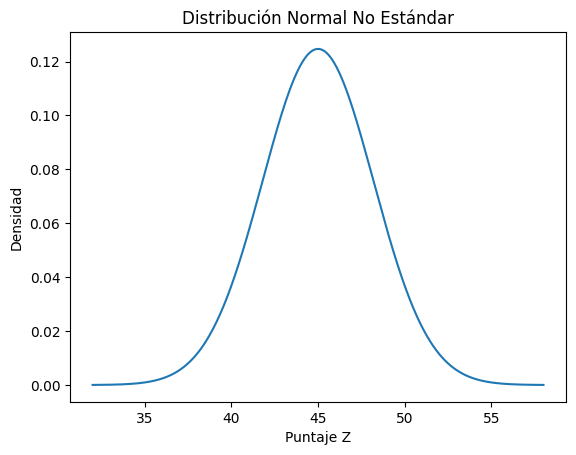

In [14]:
x = np.linspace(32, 58, 800) #Se usa la regla de media (más o menos)4*Desv_est
y = norm.pdf(x, 45, 3.2)

plt.plot(x, y)
plt.title("Distribución Normal No Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.show()

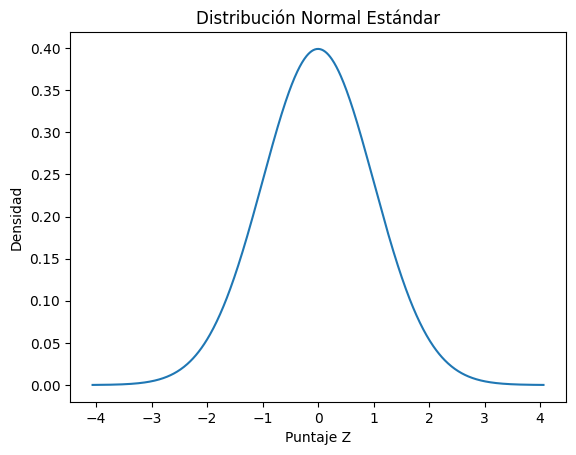

In [15]:
# Datos originales
x = np.linspace(32, 58, 800)
mu = 45
sigma = 3.2

#Se estandarizan los valores de x, a partir del cálculo de puntuaciones
z = (x - mu) / sigma

#Se calcula la distribución normal con media = 0 y desv_est = 1
y_estandar = norm.pdf(z, 0, 1)

#Se realiza el gráfico
plt.plot(z, y_estandar)
plt.title("Distribución Normal Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.show()

In [16]:
mu_ind = 45
sigma_ind = 3.2
x_critico = 50

# Método 1: Estandarizando manualmente
z_industrial = (x_critico - mu_ind) / sigma_ind
prob_normal = norm.cdf(z_industrial)
prob_exceso = 1 - norm.cdf(z_industrial)

print(f"El valor de Z es {z_industrial}")
print(f"La probabilidad de que tarde menos de {x_critico} segundos es: {prob_normal:4f}")
print(f"La probabilidad de que tarde más de {x_critico} segundos es: {prob_exceso:4f}")

El valor de Z es 1.5625
La probabilidad de que tarde menos de 50 segundos es: 0.940915
La probabilidad de que tarde más de 50 segundos es: 0.059085


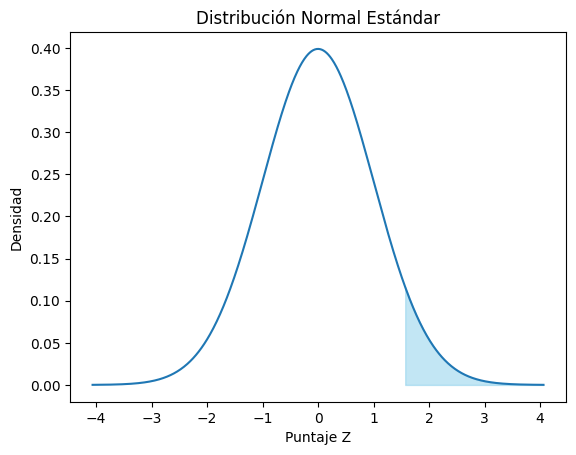

In [17]:
# Datos originales
x = np.linspace(32, 58, 800)
mu = 45
sigma = 3.2

#Se estandarizan los valores de x, a partir del cálculo de puntuaciones
z = (x - mu) / sigma

#Se calcula la distribución normal con media = 0 y desv_est = 1
y_estandar = norm.pdf(z, 0, 1)

#Se realiza el gráfico
plt.plot(z, y_estandar)
plt.title("Distribución Normal Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.fill_between(z, y_estandar, where=(z >= 1.5625), color='skyblue', alpha=0.5)
plt.show()

In [18]:
# Calcular el valor Z que acumula el 90% (0.90) del área
area_objetivo = 0.9409 #Probabilidad del problema
z_limite = norm.ppf(area_objetivo)
print(f"El valor Z para el percentil 90 es: {z_limite:.4f}")

El valor Z para el percentil 90 es: 1.5624


Para calcula x, se despeja de la formula de la puntuación

$$ x = μ + (z*σ)$$

In [19]:
x = mu + (z_limite * sigma)
print(f"El valor de x para el percentil {area_objetivo} es: {x:.2f}")

El valor de x para el percentil 0.9409 es: 50.00


##Teorema del límite central

###Distribución muestral de la media.

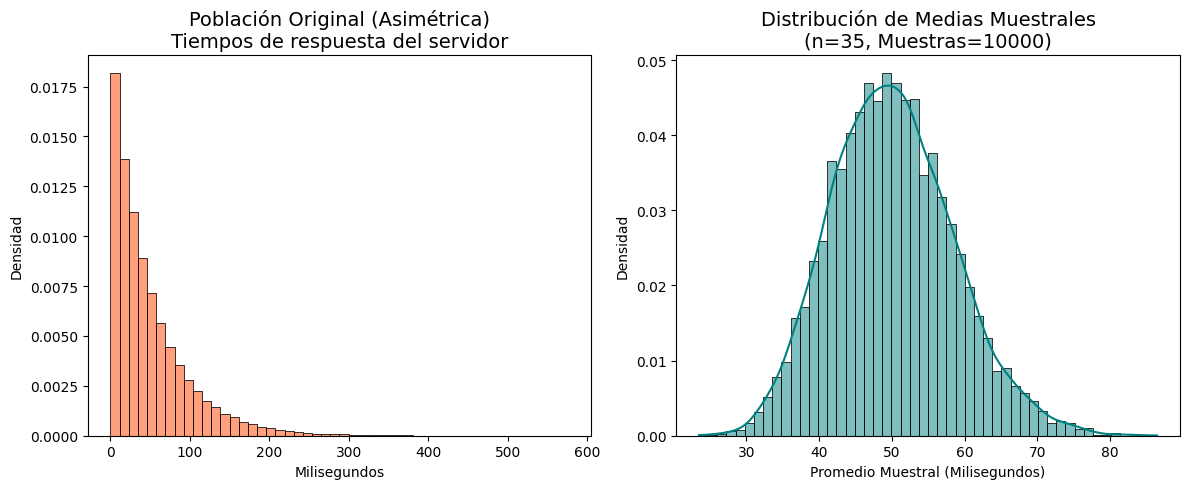

--- COMPROBACIÓN DEL TEOREMA DEL LÍMITE CENTRAL ---
Media real de la Población: 50.18
Media de las Medias Muestrales: 50.06


In [23]:
plt.rcParams['figure.figsize'] = (12, 5)

# 1. CREAMOS LA POBLACIÓN (Altamente asimétrica/sesgada)
# Ejemplo: Tiempos de respuesta de un servidor en milisegundos
# (Muchos responden rápido, unos pocos tardan muchísimo)
poblacion = np.random.exponential(scale=50, size=100000)

# 2. EXPERIMENTO: Extraer muestras y calcular sus promedios
tamano_muestra = 35  # La regla del n >= 30
numero_de_muestras = 10000
medias_muestrales = []

for _ in range(numero_de_muestras):
    muestra = np.random.choice(poblacion, size=tamano_muestra)
    medias_muestrales.append(np.mean(muestra))

# 3. VISUALIZACIÓN COMPARATIVA (La magia del TLC)
fig, axes = plt.subplots(1, 2)

# Gráfico A: La población original (Caótica/Sesgada)
sns.histplot(poblacion, bins=50, color="coral", ax=axes[0], stat="density")
axes[0].set_title("Población Original (Asimétrica)\nTiempos de respuesta del servidor", fontsize=14)
axes[0].set_xlabel("Milisegundos")
axes[0].set_ylabel("Densidad")

# Gráfico B: La distribución de las Medias Muestrales (Campana de Gauss)
sns.histplot(medias_muestrales, bins=50, color="teal", ax=axes[1], stat="density", kde=True)
axes[1].set_title(f"Distribución de Medias Muestrales\n(n={tamano_muestra}, Muestras={numero_de_muestras})", fontsize=14)
axes[1].set_xlabel("Promedio Muestral (Milisegundos)")
axes[1].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

# 4. COMPROBACIÓN NUMÉRICA
print("--- COMPROBACIÓN DEL TEOREMA DEL LÍMITE CENTRAL ---")
print(f"Media real de la Población: {np.mean(poblacion):.2f}")
print(f"Media de las Medias Muestrales: {np.mean(medias_muestrales):.2f}")

###Distribución muestral de la varianza.


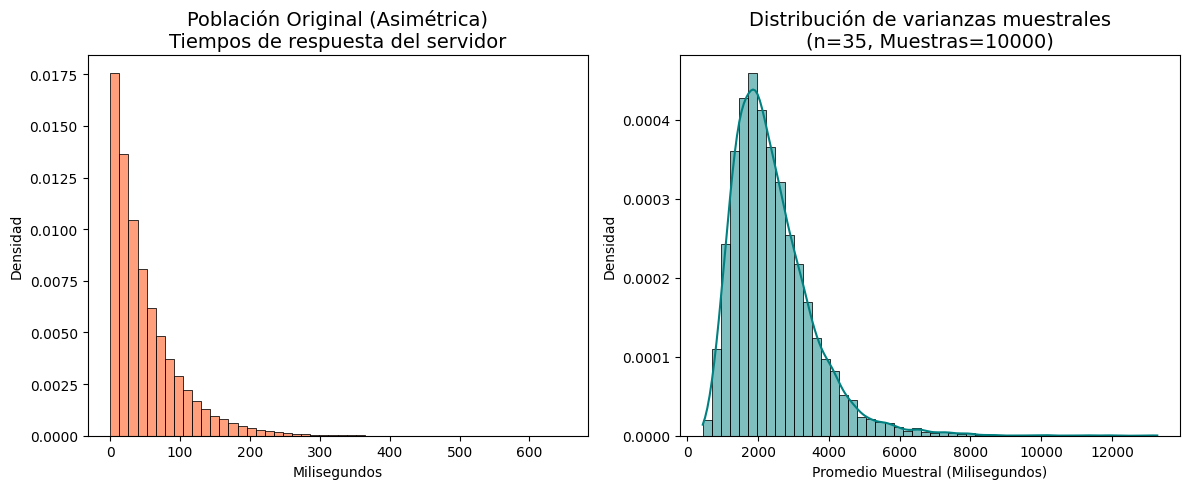

--- COMPROBACIÓN DEL TEOREMA DEL LÍMITE CENTRAL ---
Media real de la Población: 49.99
Media de las Medias Muestrales: 2400.38


In [24]:
plt.rcParams['figure.figsize'] = (12, 5)

# 1. CREAMOS LA POBLACIÓN (Altamente asimétrica/sesgada)
# Ejemplo: Tiempos de respuesta de un servidor en milisegundos
# (Muchos responden rápido, unos pocos tardan muchísimo)
poblacion = np.random.exponential(scale=50, size=100000)

# 2. EXPERIMENTO: Extraer muestras y calcular sus promedios
tamano_muestra = 35  # La regla del n >= 30
numero_de_muestras = 10000
medias_muestrales = []

for _ in range(numero_de_muestras):
    muestra = np.random.choice(poblacion, size=tamano_muestra)
    medias_muestrales.append(np.var(muestra))

# 3. VISUALIZACIÓN COMPARATIVA (La magia del TLC)
fig, axes = plt.subplots(1, 2)

# Gráfico A: La población original (Caótica/Sesgada)
sns.histplot(poblacion, bins=50, color="coral", ax=axes[0], stat="density")
axes[0].set_title("Población Original (Asimétrica)\nTiempos de respuesta del servidor", fontsize=14)
axes[0].set_xlabel("Milisegundos")
axes[0].set_ylabel("Densidad")

# Gráfico B: La distribución de las Medias Muestrales (Campana de Gauss)
sns.histplot(medias_muestrales, bins=50, color="teal", ax=axes[1], stat="density", kde=True)
axes[1].set_title(f"Distribución de varianzas muestrales\n(n={tamano_muestra}, Muestras={numero_de_muestras})", fontsize=14)
axes[1].set_xlabel("Promedio Muestral (Milisegundos)")
axes[1].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

# 4. COMPROBACIÓN NUMÉRICA
print("--- COMPROBACIÓN DEL TEOREMA DEL LÍMITE CENTRAL ---")
print(f"Media real de la Población: {np.mean(poblacion):.2f}")
print(f"Media de las Medias Muestrales: {np.mean(medias_muestrales):.2f}")

## Intervalos de confianza para la media

In [41]:
#Calculador de T-student y errores.
from scipy.stats import t

n=49
s = 21
df = n-1
se = s / np.sqrt(n)

t_crit = t.ppf(0.99, df)
E = t_crit * se
print(f"El valor de la distribución t-student crítico es de: {t_crit:.3f}")
print(f"El error es de: {E:.3f}")

El valor de la distribución t-student crítico es de: 2.407
El error es de: 7.220


### Problema: Intervalo de confianza para el tiempo de vigilia

Se realizó un ensayo clínico para probar la efectividad del fármaco *zopiclona* en el tratamiento del insomnio en sujetos mayores.

Antes del tratamiento con zopiclona, 16 sujetos tuvieron un tiempo de vigilia medio de **102.8 minutos**. Después del tratamiento con zopiclona, los 16 sujetos tuvieron un tiempo de vigilia medio de **98.9 minutos** y una desviación estándar de **42.3 minutos** (con base en los datos de *“Cognitive Behavioral Therapy vs Zopiclone for Treatment of Chronic Primary Insomnia in Older Adults”*, de Sivertsen et al., en *Journal of the American Medical Association*, vol. 295, núm. 24).

Suponga que los 16 valores muestrales parecen ser de una población normalmente distribuida.

**Preguntas:**

1. Construya una estimación del **intervalo de confianza del 98%** para el tiempo de vigilia medio de una población con tratamiento de zopiclona.
2. ¿Qué sugiere el resultado sobre el tiempo de vigilia medio de **102.8 minutos** antes del tratamiento?
3. ¿La zopiclona parece ser efectiva?

In [38]:
# Datos
n = 16
x_bar = 98.9
s = 42.3
df = n - 1
valor_antes = 102.8

se = s / np.sqrt(n)

x_min = x_bar - 4*se
x_max = x_bar + 4*se

x = np.linspace(x_min, x_max, 1000)

# Distribución t (reescalada)
y = t.pdf((x - x_bar)/se, df)

# Valor crítico
t_crit = t.ppf(0.99, df)
E = t_crit * se

# Intervalo
lim_inf = x_bar - E
lim_sup = x_bar + E

print(f"El valor de la distribución t-student crítico es de: {t_crit:.3f}")
print(f"El intervalo de confianza es: ({lim_inf:.2f}, {lim_sup:.2f})")



El valor de la distribución t-student crítico es de: 2.602
El intervalo de confianza es: (71.38, 126.42)


Text(0.5, 1.0, 'Intervalo de confianza 98% (Distribución t)')

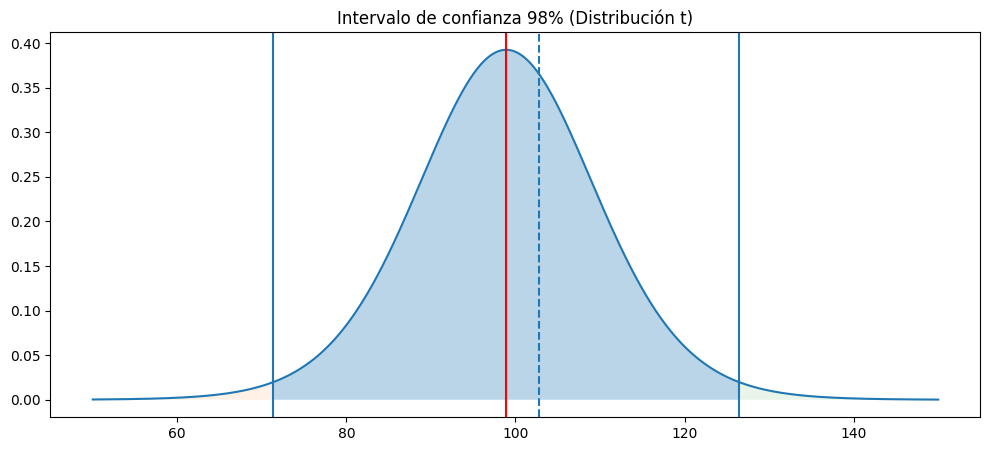

In [29]:
# Gráfica base
plt.plot(x, y)

# Sombreado dentro del intervalo
plt.fill_between(x, y, where=(x >= lim_inf) & (x <= lim_sup), alpha=0.3)

# Sombreado fuera del intervalo (colas)
plt.fill_between(x, y, where=(x < lim_inf), alpha=0.1)
plt.fill_between(x, y, where=(x > lim_sup), alpha=0.1)

# Líneas del intervalo
plt.axvline(lim_inf)
plt.axvline(lim_sup)

# Media muestral
plt.axvline(x_bar, color='r')

# Línea punteada para el valor antes del tratamiento
plt.axvline(valor_antes, linestyle='--')

# Título
plt.title("Intervalo de confianza 98% (Distribución t)")